<h1><p style="text-align:center;">Raport 2 - statystyka</p></h1>

## Zad 1  
Z populacji generalnej o rozkładzie normalnym N($\mu$, $\sigma = 0.2$) pobrano próbę (dane dołączone do
listy). Dla $\alpha = 0.05$ zweryfikuj hipotezy:  
▶ $\mu \not = 1.5$,  
▶ $\mu > 1.5$,  
▶ $\mu < 1.5$.  
Narysuj odpowiednie obszary kytyczne i wyznacz p-wartości dla każdej z powyższych hipotez. Odpowiedz na pytanie co stanie się kiedy zwiększymy bądź zmniejszymy poziom ufności.

### Rozwiązanie
#### Wzory
Z faktu, że $\sigma$ jest znana i wynosi $\sigma = 0.2$ może my zastosować test Z.
Do wyznaczenia statystyki testowej Z został użyty wzór:
$$Z = \frac{(\bar x - \mu_{0})}{\frac{\sigma}{\sqrt{n}}}  \text{, dla }  \mu_{0}=1.5$$

Przedziały krytyczne wyznacznono na podstawie kwantyli rozkładu normalnego standardowego:
1. Dla testu obustronnego $H_1:\mu \not = 1.5$
$$(-\infty;-z_{1-\frac{\alpha}{2}}] \cup [z_{1-\frac{\alpha}{2}};\infty)$$
2. Dla testu lewostronnego $H_1:\mu < 1.5$
$$(-\infty;-z_{\alpha}]$$
3. Dla testu prawostronnego $H_1:\mu > 1.5$
$$[z_{1-\alpha};\infty)$$

P-wartość wyzanczono z wzoru:
1. Dla testu obustronnego $H_1:\mu \not = 1.5$
$$p_{value} = 2(1-\Phi(|Z|))$$
2. Dla testu lewostronnego $H_1:\mu < 1.5$
$$p_{value} = \Phi(Z)$$
3. Dla testu prawostronnego $H_1:\mu > 1.5$
$$p_{value} = 1-\Phi(Z)$$

Statystyka Z = -7.04145


H1: μ ≠ 1.5
Wartość krytyczna: 1.959963984540054
p-value = 1.9024781749976682e-12
Odrzucamy H0


H1: μ > 1.5
Wartość krytyczna: 1.6448536269514722
p-value = 0.9999999999990488
Brak podstaw do odrzucenia H0


H1: μ < 1.5
Wartość krytyczna: -1.6448536269514729
p-value = 9.51241291241344e-13
Odrzucamy H0


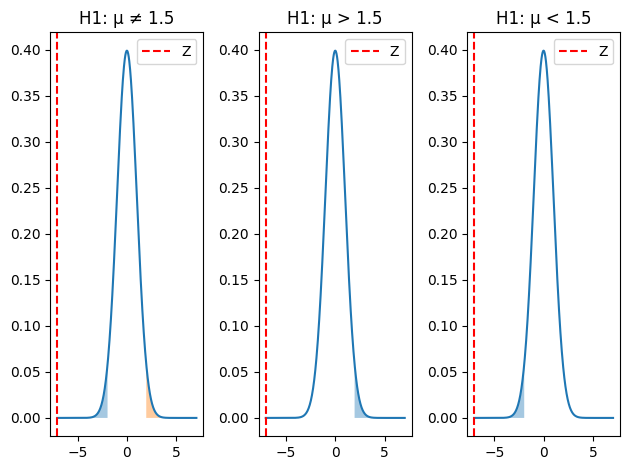

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def tesowanie_h0_srednia(alpha,sigma,mu0):
    with open('dane1.txt', 'r', encoding='utf-8') as plik:
        dane = [float(linia) for linia in plik]
    n = len(dane)
    x_sr = np.mean(dane)
    
    Z = (x_sr - mu0)/(sigma/np.sqrt(n))
    print("Statystyka Z =", round(Z, 5))
    #1. H1: mi != 1.5
    print("\n")
    z_kryt1 = norm.ppf(1 - alpha / 2)
    p_value1 = 2 * (1 - norm.cdf(abs(Z)))
    print("H1: μ ≠ 1.5")
    print("Wartość krytyczna:", z_kryt1)
    print("p-value =", p_value1)

    if abs(Z) > z_kryt1:
        print("Odrzucamy H0")
    else:
        print("Brak podstaw do odrzucenia H0")

    #2. H1: mi > 1.5
    print("\n")

    z_kryt2 = norm.ppf(1 - alpha)
    p_value2 = 1 - norm.cdf(Z)

    print("H1: μ > 1.5")
    print("Wartość krytyczna:", z_kryt2)
    print("p-value =", p_value2)

    if Z > z_kryt2:
        print("Odrzucamy H0")
    else:
        print("Brak podstaw do odrzucenia H0")

    # 3. H1: mi < 1.5
    print("\n")

    z_kryt3 = norm.ppf(alpha)
    p_value3 = norm.cdf(Z)

    print("H1: μ < 1.5")
    print("Wartość krytyczna:", z_kryt3)
    print("p-value =", p_value3)

    if Z < z_kryt3:
        print("Odrzucamy H0")
    else:
        print("Brak podstaw do odrzucenia H0")
    x=np.zeros
    if abs(Z)>=4:
        x = np.linspace(Z, -Z, 500)
    else:
        x = np.linspace(4, -4, 500)
    y = norm.pdf(x)

    plt.subplot(1,3,1)
    plt.plot(x,y)
    plt.fill_between(x, 0, y, where=(x <= -z_kryt1),alpha=0.4)
    plt.fill_between(x, 0, y,where=(x >= z_kryt1), alpha=0.4)
    plt.axvline(Z, color='red', linestyle='--', label='Z')
    plt.title("H1: μ ≠ 1.5")
    plt.legend()
    plt.subplot(1,3,2)
    plt.plot(x,y)
    plt.fill_between(x, 0, y,where=(x >= z_kryt1), alpha=0.4)
    plt.axvline(Z, color='red', linestyle='--', label='Z')
    plt.title("H1: μ > 1.5")
    plt.legend()
    plt.subplot(1,3,3)
    plt.plot(x,y)
    plt.fill_between(x, 0, y,where=(x <= -z_kryt1), alpha=0.4)
    plt.axvline(Z, color='red', linestyle='--', label='Z')
    plt.title("H1: μ < 1.5")
    plt.legend()
    plt.tight_layout()
    plt.show()

tesowanie_h0_srednia(0.05, 0.2, 1.5)


### Wniosek dla H0  
Statystyka testowa jest silnie ujemna (Z=−7.04), czyli wartość krytyczna znajduje się w lewym ogonie. W przedziale obustornnym jak i prawostronnym odrzucana jest hipoteza zerowa H0:$\mu=1.5$. Dlatego na poziomie istotności $\alpha=0.05$ istnieją bardzo silne podstawy do odrzucenia hipotezy zerowej. Jest też wysoce prawdopodobne że średnia rozkładu jest mniejsza od 1.5.
### Testowanie wpływu poziomu istotności $\alpha$, dla $\alpha=0.01$ i $\alpha=0.1$

Statystyka Z = -7.04145


H1: μ ≠ 1.5
Wartość krytyczna: 2.5758293035489004
p-value = 1.9024781749976682e-12
Odrzucamy H0


H1: μ > 1.5
Wartość krytyczna: 2.3263478740408408
p-value = 0.9999999999990488
Brak podstaw do odrzucenia H0


H1: μ < 1.5
Wartość krytyczna: -2.3263478740408408
p-value = 9.51241291241344e-13
Odrzucamy H0


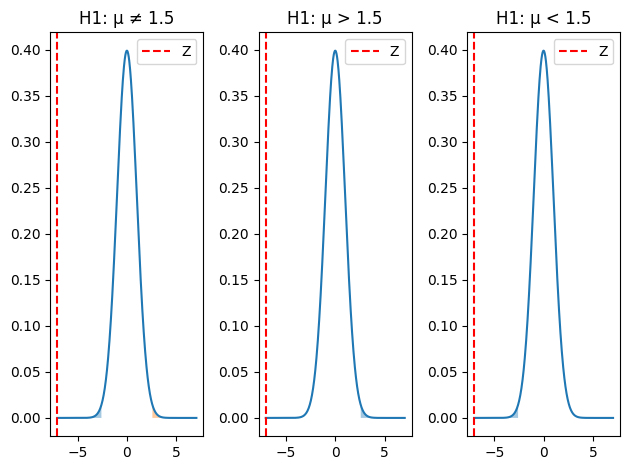

In [50]:
tesowanie_h0_srednia(0.01, 0.2, 1.5)

Statystyka Z = -7.04145


H1: μ ≠ 1.5
Wartość krytyczna: 1.6448536269514722
p-value = 1.9024781749976682e-12
Odrzucamy H0


H1: μ > 1.5
Wartość krytyczna: 1.2815515655446004
p-value = 0.9999999999990488
Brak podstaw do odrzucenia H0


H1: μ < 1.5
Wartość krytyczna: -1.2815515655446004
p-value = 9.51241291241344e-13
Odrzucamy H0


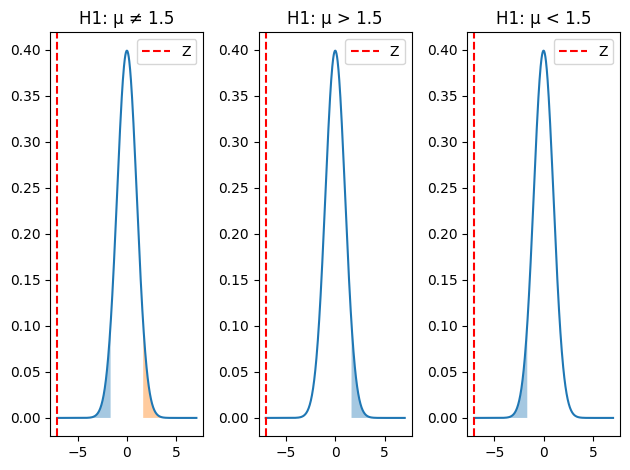

In [51]:
tesowanie_h0_srednia(0.1, 0.2, 1.5)

### Wnioski na temat wpływu zmiany poziomu istotności $\alpha$

Otrzymana wartość statystyki testowej Z=−7.04145 jest znacznie mniejsza od lewostronnych wartości krytycznych zarówno dla $\alpha=0.01$, jak i $\alpha=0.1$, co wskazuje na silne przesłanki przemawiające za tym, że średnia jest mniejsza od 1.5. Potwierdzają to również bardzo małe p-wartości: dla testu lewostronnego $p_{value}\approx 9.51⋅10^{−13}$, a dla testu dwustronnego $p_{value} \approx 1.90⋅10^{−12}$, które są znacznie mniejsze od obu analizowanych poziomów istotności.

Zwiększenie poziomu istotności z $\alpha=0.01$ do $\alpha=0.1$ powoduje powiększenie obszaru krytycznego, co teoretycznie ułatwia odrzucenie hipotezy zerowej. Jednak w tym przypadku decyzja testowa nie ulega zmianie, ponieważ p-wartości są ekstremalnie małe i pozostają znacznie poniżej obu poziomów istotności. Oznacza to, że uzyskany wynik jest bardzo silnie istotny statystycznie i wniosek o odrzuceniu hipotezy H0 na rzecz H1:$\mu<1.5$ jest stabilny niezależnie od wyboru α spośród analizowanych wartości.


## Zad 2
Z populacji generalnej o rozkładzie normalnym N($mu = 0.2$, $\sigma$) pobrano próbę (dane dołączone do listy). Dla $\alpha = 0.05$ zweryfikuj hipotezy:  
▶ $\sigma^2 \not = 1.5$,  
▶ $\sigma^2 > 1.5$,  
▶ $\sigma^2 < 1.5$.  
Narysuj odpowiednie obszary kytyczne i wyznacz p-wartości dla każdej z powyższych hipotez. Odpowiedz na pytanie co stanie się kiedy zwiększymy bądź zmniejszymy poziom ufności

### Rozwiązanie

#### Wzory

Z faktu, że populacja generalna ma rozkład normalny oraz znana jest wartość średniej ($\mu = 0.2$), do weryfikacji hipotez dotyczących wariancji zastosowano test ($\chi^2$).

Do wyznaczenia statystyki testowej ($\chi^2$) został użyty wzór:

$$\chi^2=\frac{\sum_{i=1}^{n}(x_i-\mu)^2}{\sigma_0^2} \text{, dla } \mu=0.2,\ \sigma_0^2=1.5$$

Przedziały krytyczne wyznaczono na podstawie kwantyli rozkładu chi-kwadrat:

1. Dla testu obustronnego $(H_1:\sigma^2 \not = 1.5)$

$$[0;\chi^2_{\frac{\alpha}{2},n}] \cup [\chi^2_{1-\frac{\alpha}{2},n};\infty)$$

2. Dla testu lewostronnego $(H_1:\sigma^2 < 1.5)$

$$[0;\chi^2_{\alpha,n}]$$

3. Dla testu prawostronnego $(H_1:\sigma^2 > 1.5)$

$$[\chi^2_{1-\alpha,n};\infty)$$

P-wartość wyznaczono z wzoru:

1. Dla testu obustronnego $(H_1:\sigma^2 \not = 1.5)$

$$p_{value}=2\min{(F(\chi^2),1-F(\chi^2))}$$

2. Dla testu lewostronnego $(H_1:\sigma^2 < 1.5)$

$$p_{value}=F(\chi^2)$$

3. Dla testu prawostronnego $(H_1:\sigma^2 > 1.5)$

$$p_{value}=1-F(\chi^2)$$

gdzie (F) oznacza dystrybuantę rozkładu ($\chi^2$) o (n) stopniach swobody.


Statystyka chi2 = 1112.57991


H1: σ² ≠ 1.5
Wartość krytyczna lewa: 913.3009983021134
Wartość krytyczna prawa: 1088.4870677259353
p-value = 0.013686145574530961
Odrzucamy H0


H1: σ² > 1.5
Wartość krytyczna: 1073.6426506574246
p-value = 0.006843072787265481
Odrzucamy H0


H1: σ² < 1.5
Wartość krytyczna: 926.6311609204329
p-value = 0.9931569272127345
Brak podstaw do odrzucenia H0


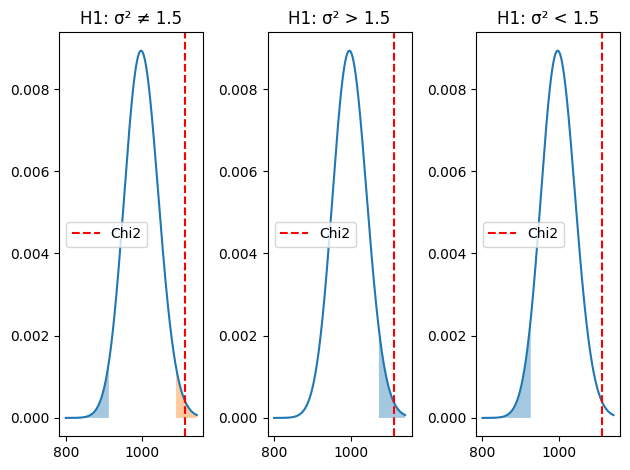

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

def tesowanie_h0_wariancja(alpha,sigma20,mu):
    with open('dane2.txt', 'r', encoding='utf-8') as plik:
        dane = [float(linia) for linia in plik]
    n = len(dane)
    sum = 0
    for i in range(n):
        sum += (dane[i]-mu)**2
    Chi2 = sum/sigma20

    print("Statystyka chi2 =", round(Chi2, 5))

    #1. H1: sigma != 1.5
    print("\n")
    chi_kryt1_left = chi2.ppf(alpha/2,n-1)
    chi_kryt1_right = chi2.ppf(1 - alpha/2,n-1)

    p_value1 = 2*min(chi2.cdf(Chi2, n-1),1-chi2.cdf(Chi2, n-1))
    print("H1: σ² ≠ 1.5")
    print("Wartość krytyczna lewa:", chi_kryt1_left)
    print("Wartość krytyczna prawa:", chi_kryt1_right)
    print("p-value =", p_value1)

    if Chi2 > chi_kryt1_right or Chi2 < chi_kryt1_left:
        print("Odrzucamy H0")
    else:
        print("Brak podstaw do odrzucenia H0")

    #2. H1: sigma > 1.5
    print("\n")
    chi_kryt2_right = chi2.ppf(1 - alpha,n-1)

    p_value2 = 1-chi2.cdf(Chi2, n-1)
    print("H1: σ² > 1.5")
    print("Wartość krytyczna:", chi_kryt2_right)
    print("p-value =", p_value2)

    if Chi2 > chi_kryt2_right:
        print("Odrzucamy H0")
    else:
        print("Brak podstaw do odrzucenia H0")

    
    #3. H1: sigma < 1.5
    print("\n")
    chi_kryt3_left = chi2.ppf(alpha,n-1)

    p_value3 = chi2.cdf(Chi2, n-1)
    print("H1: σ² < 1.5")
    print("Wartość krytyczna:", chi_kryt3_left)
    print("p-value =", p_value3)

    if Chi2 < chi_kryt3_left:
        print("Odrzucamy H0")
    else:
        print("Brak podstaw do odrzucenia H0")

    x = np.linspace(800, chi2.ppf(0.999, n-1), 500)
    y = chi2.pdf(x,n-1)

    plt.subplot(1,3,1)
    plt.plot(x,y)
    plt.fill_between(x, 0, y, where=(x <= chi_kryt1_left),alpha=0.4)
    plt.fill_between(x, 0, y,where=(x >= chi_kryt1_right), alpha=0.4)
    plt.axvline(Chi2, color='red', linestyle='--', label='Chi2')
    plt.title("H1: σ² ≠ 1.5")
    plt.legend()
    plt.subplot(1,3,2)
    plt.plot(x,y)
    plt.fill_between(x, 0, y,where=(x >= chi_kryt2_right), alpha=0.4)
    plt.axvline(Chi2, color='red', linestyle='--', label='Chi2')
    plt.title("H1: σ² > 1.5")
    plt.legend()
    plt.subplot(1,3,3)
    plt.plot(x,y)
    plt.fill_between(x, 0, y,where=(x <= chi_kryt3_left), alpha=0.4)
    plt.axvline(Chi2, color='red', linestyle='--', label='Chi2')
    plt.title("H1: σ² < 1.5")
    plt.legend()
    plt.tight_layout()
    plt.show()

tesowanie_h0_wariancja(0.05, 1.5, 0.2)


### Wniosek dla H0

Ponieważ statystyka testowa znajduje się w prawym ogonie rozkładu ($\chi^2=1110.96845$). Testy obustronny i lewostronny wykazały odrzucenie hipotezy zerowej $\sigma^2 = 1.5$. Dlatego na poziomie istotności $\alpha=0.05$ istnieją bardzo silne podstawy do odrzucenia hipotezy zerowej. Z testów również wynika że wariancja jest najprawdopodobnie większa od 1.5
### Testowanie wpływu poziomu istotności $\alpha$, dla $\alpha=0.006$ i $\alpha=0.1$

Statystyka chi2 = 1112.57991


H1: σ² ≠ 1.5
Wartość krytyczna lewa: 880.5389943262
Wartość krytyczna prawa: 1126.1926861585694
p-value = 0.013686145574530961
Brak podstaw do odrzucenia H0


H1: σ² > 1.5
Wartość krytyczna: 1114.8258860084713
p-value = 0.006843072787265481
Brak podstaw do odrzucenia H0


H1: σ² < 1.5
Wartość krytyczna: 890.2538121557938
p-value = 0.9931569272127345
Brak podstaw do odrzucenia H0


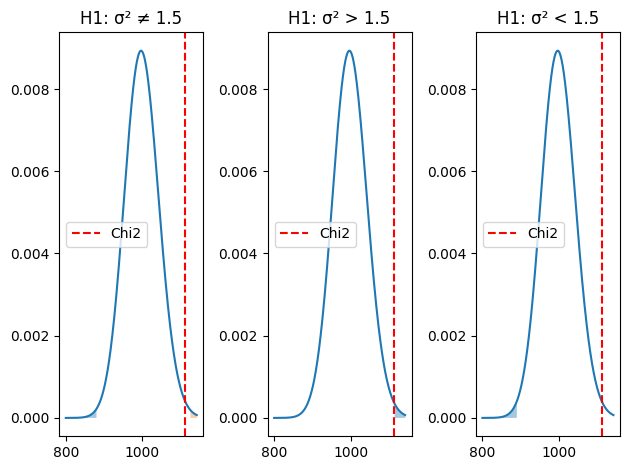

In [53]:
tesowanie_h0_wariancja(0.006, 1.5,0.2)

Statystyka chi2 = 1112.57991


H1: σ² ≠ 1.5
Wartość krytyczna lewa: 926.6311609204329
Wartość krytyczna prawa: 1073.6426506574246
p-value = 0.013686145574530961
Odrzucamy H0


H1: σ² > 1.5
Wartość krytyczna: 1056.6952292962342
p-value = 0.006843072787265481
Odrzucamy H0


H1: σ² < 1.5
Wartość krytyczna: 942.1612343926897
p-value = 0.9931569272127345
Brak podstaw do odrzucenia H0


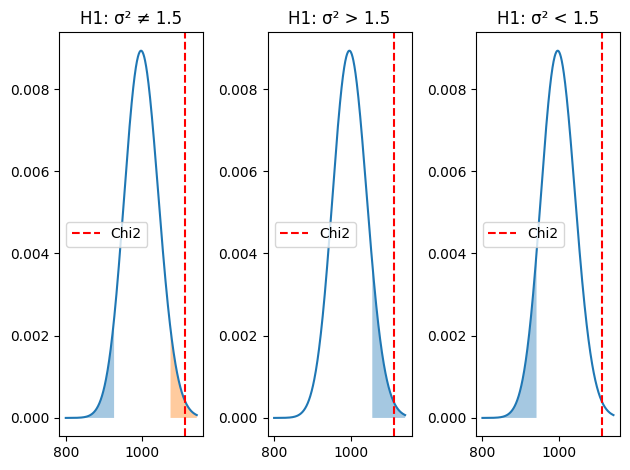

In [54]:
tesowanie_h0_wariancja(0.1,1.5,0.2)

### Wnioski dla wpływu poziomu istotności $\alpha$

Dla poziomu istotności $\alpha=0.1$ istnieją podstawy do odrzucenia hipotezy zerowej o wariancji równej 1.5 na rzecz hipotezy alternatywnej, że wariancja jest większa od 1.5 (a także na rzecz hipotezy dwustronnej, że wariancja jest różna od 1.5). Natomiast po zmniejszeniu poziomu istotności do $\alpha=0.006$ nie ma podstaw do odrzucenia hipotezy zerowej.

Wynika to z faktu, że wraz ze zmniejszaniem poziomu istotności obszar krytyczny staje się mniejszy, przez co odrzucenie hipotezy zerowej wymaga silniejszych dowodów pochodzących z próby. W analizowanym przypadku p-wartość testu prawostronnego wynosi około 0.0068, czyli jest mniejsza od 0.1, lecz większa od 0.006. Dlatego hipoteza zerowa zostaje odrzucona dla $\alpha=0.1$, ale nie zostaje odrzucona dla $\alpha=0.006$. Oznacza to, że wynik jest istotny statystycznie przy mniej rygorystycznych poziomach istotności, natomiast nie jest istotny przy bardzo restrykcyjnym poziomie $\alpha=0.006$.

## Zad 3
W tej części przeprowadzono symulacyjne wyznaczanie błędu I rodzaju, błędu II rodzaju oraz mocy testu dla testu średniej populacji przy znanym odchyleniu standardowym. W przeciwieństwie do poprzednich zadań nie wykorzystuje się danych empirycznych, lecz dane generowane losowo z odpowiednich rozkładów normalnych.

Przyjęto następujące parametry:

- wartość średniej w hipotezie zerowej: $\mu_0 = 1.5$,
- odchylenie standardowe populacji: $\sigma = 0.2$,
- liczebność próby: $n = 1000$,
- poziom istotności: $\alpha = 0.05$,
- liczba symulacji: $N = 1000$.

Dla każdej wygenerowanej próby wyznaczana jest statystyka testowa

$$
Z=\frac{\overline{X}-\mu_0}{\sigma/\sqrt{n}} = \frac{\overline{X}-1.5}{0.2/\sqrt{1000}},
$$

gdzie $\overline{X}$ oznacza średnią z próby.

---

# 3.1 Błąd I rodzaju

Błąd I rodzaju oznacza odrzucenie prawdziwej hipotezy zerowej. Jego teoretyczna wartość jest równa przyjętemu poziomowi istotności $\alpha$.

W celu oszacowania błędu I rodzaju generowano próby z rozkładu normalnego

$$
X \sim N(1.5, 0.2),
$$

czyli zgodnie z hipotezą zerową. Dla każdej próby obliczano wartość statystyki testowej oraz sprawdzano, czy znajduje się ona w obszarze krytycznym. Procedurę powtórzono $N=1000$ razy.

Symulacyjne przybliżenie błędu I rodzaju wyznaczono ze wzoru

$$
\hat{\alpha}
=
\frac{\#\{\text{odrzuceń }H_0\}}{N}.
$$

Otrzymana wartość powinna być zbliżona do poziomu istotności $\alpha = 0.05$.

---

# 3.2 Błąd II rodzaju

Błąd II rodzaju oznacza nieodrzucenie fałszywej hipotezy zerowej. Jego wartość zależy od rzeczywistej wartości parametru oraz odległości tej wartości od parametru określonego w hipotezie zerowej.

W celu oszacowania błędu II rodzaju generowano dane z rozkładu

$$
X \sim N(\mu, 0.2),
$$

gdzie $\mu \neq 1.5$.

Rozważono wartości średniej bliskie wartości określonej przez hipotezę zerową:
- dla testu dwustronnego:
  $\mu = 1.450,\;1.452,\;1.454... \;1.548,\;1.550$

Dla każdej wartości parametru wykonywano $N=1000$ symulacji. Błąd II rodzaju oszacowano jako udział przypadków, w których hipoteza zerowa nie została odrzucona:

$$
\hat{\beta}
=
\frac{\#\{\text{brak odrzucenia }H_0\}}{N}.
$$

Wyniki przedstawiono w formie tabelarycznej.

---

# 3.3 Moc testu

Moc testu jest prawdopodobieństwem poprawnego odrzucenia fałszywej hipotezy zerowej. Stanowi dopełnienie błędu II rodzaju:

$$
\text{Moc testu} = 1-\beta.
$$

Po oszacowaniu błędu II rodzaju dla każdej rozważanej wartości parametru obliczono moc testu. Oczekuje się, że wraz ze wzrostem odległości rzeczywistej wartości średniej od wartości określonej w hipotezie zerowej błąd II rodzaju będzie malał, natomiast moc testu będzie rosła.

In [ ]:
#3.1
alpha = [1, 0.5,0.25,0.1,0.05]
mu0 = 1.5
sigma = 0.2

n = 1000
N = 1000
M = 200

def calc_odrzucenia(alpha, mu0 = 1.5, sigma = 0.2):
    odrzucenia = 0
    #Kwantyl q_(1-alpha/2)
    z_critical = norm.ppf(1 - alpha/2)

    for _ in range(N):

        x = np.random.normal(mu0, sigma, n)

        z = (np.mean(x) - mu0) / (sigma / np.sqrt(n))

        if abs(z) > z_critical:
            odrzucenia += 1

    blad_I = odrzucenia / N

    print(f"Błąd I rodzaju = {blad_I:.4f}, Alpha = {alpha}")
for a in alpha:
    calc_odrzucenia(a)
odrzut_m =[]
for i in range(M):
    m = calc_odrzucenia(0.05)
    odrzut_m.append(m)
srednia = np.mean(odrzut_m)
print(f"średnia Błędu I rodzaju w 200 próbach = {srednia}, Alpha = 0.05")

Błąd I rodzaju = 1.0000, Alpha = 1
Błąd I rodzaju = 0.4870, Alpha = 0.5
Błąd I rodzaju = 0.2470, Alpha = 0.25
Błąd I rodzaju = 0.1020, Alpha = 0.1
Błąd I rodzaju = 0.0550, Alpha = 0.05
Błąd I rodzaju = 0.0600, Alpha = 0.05
Błąd I rodzaju = 0.0430, Alpha = 0.05
Błąd I rodzaju = 0.0660, Alpha = 0.05
Błąd I rodzaju = 0.0450, Alpha = 0.05
Błąd I rodzaju = 0.0660, Alpha = 0.05
Błąd I rodzaju = 0.0470, Alpha = 0.05
Błąd I rodzaju = 0.0450, Alpha = 0.05
Błąd I rodzaju = 0.0490, Alpha = 0.05
Błąd I rodzaju = 0.0540, Alpha = 0.05
Błąd I rodzaju = 0.0530, Alpha = 0.05
Błąd I rodzaju = 0.0570, Alpha = 0.05
Błąd I rodzaju = 0.0510, Alpha = 0.05
Błąd I rodzaju = 0.0550, Alpha = 0.05
Błąd I rodzaju = 0.0320, Alpha = 0.05
Błąd I rodzaju = 0.0650, Alpha = 0.05
Błąd I rodzaju = 0.0380, Alpha = 0.05
Błąd I rodzaju = 0.0510, Alpha = 0.05
Błąd I rodzaju = 0.0580, Alpha = 0.05
Błąd I rodzaju = 0.0470, Alpha = 0.05
Błąd I rodzaju = 0.0530, Alpha = 0.05
Błąd I rodzaju = 0.0580, Alpha = 0.05
Błąd I rodzaju = 

c:\Users\Kiepson4K\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Kiepson4K\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [90]:
mu_alt = np.linspace(1.45,1.55,50)

beta_lista = []
moc_lista = []

z_critical= norm.ppf(1 - 0.5/2)
for mu in mu_alt:

    nie_odrzucenia = 0

    for _ in range(N):

        x = np.random.normal(mu, sigma, n)

        z = (np.mean(x) - mu0) / (sigma / np.sqrt(n))

        if abs(z) <= z_critical:
            nie_odrzucenia += 1

    beta = nie_odrzucenia / N
    moc = 1 - beta

    beta_lista.append(beta)
    moc_lista.append(moc)
    
print(f"{'μ':<8}{'β':<12}{'Moc':<12}")

for mu, beta, moc in zip(mu_alt, beta_lista, moc_lista):
    print(f"{mu:<8.3f}{beta:<12.4f}{moc:<12.4f}")

μ       β           Moc         
1.450   0.0000      1.0000      
1.452   0.0000      1.0000      
1.454   0.0000      1.0000      
1.456   0.0000      1.0000      
1.458   0.0000      1.0000      
1.460   0.0000      1.0000      
1.462   0.0000      1.0000      
1.464   0.0000      1.0000      
1.466   0.0000      1.0000      
1.468   0.0000      1.0000      
1.470   0.0000      1.0000      
1.472   0.0000      1.0000      
1.474   0.0020      0.9980      
1.477   0.0010      0.9990      
1.479   0.0040      0.9960      
1.481   0.0110      0.9890      
1.483   0.0270      0.9730      
1.485   0.0400      0.9600      
1.487   0.0690      0.9310      
1.489   0.1370      0.8630      
1.491   0.2050      0.7950      
1.493   0.2920      0.7080      
1.495   0.3890      0.6110      
1.497   0.4620      0.5380      
1.499   0.5070      0.4930      
1.501   0.4840      0.5160      
1.503   0.4540      0.5460      
1.505   0.3510      0.6490      
1.507   0.2830      0.7170      
1.509   0.

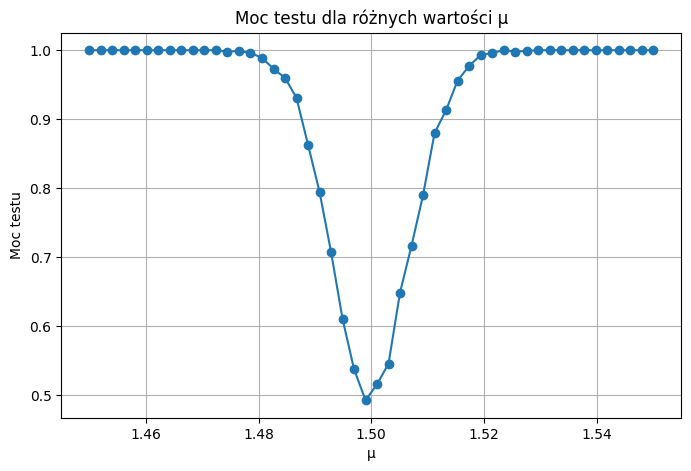

In [91]:
plt.figure(figsize=(8, 5))

plt.plot(mu_alt, moc_lista, marker="o")

plt.xlabel("μ")
plt.ylabel("Moc testu")
plt.title("Moc testu dla różnych wartości μ")
plt.grid(True)

plt.show()

## 3.2 Wariancja

In [109]:
from scipy.stats import chi2

mu = 1.5
sigma = 0.2
sigma_2 = sigma**2
alpha = 0.5

n = 1000
N = 1000

chi_left = chi2.ppf(alpha/2, df=n-1)
chi_right = chi2.ppf(1-alpha/2, df=n-1)

odrzucenia = 0

for _ in range(N):

    x = np.random.normal(mu, sigma, n)

    s2 = np.var(x, ddof=1)

    chi_stat = (n-1)*s2/sigma_2

    if chi_stat < chi_left or chi_stat > chi_right:
        odrzucenia += 1

blad_I = odrzucenia/N

print("Błąd I rodzaju =", round(blad_I,4))

Błąd I rodzaju = 0.497


In [115]:
sigma_2_alter = np.linspace(0.03, 0.05, 50)
beta_lista = []
moc_lista = []

for sigma2 in sigma_2_alter:

    nie_odrzucenia = 0

    for _ in range(N):

        x = np.random.normal(
            mu,
            np.sqrt(sigma2),
            n
        )

        s2 = np.var(x, ddof=1)

        chi_stat = (n-1)*s2/sigma2_0

        if chi_left <= chi_stat <= chi_right:
            nie_odrzucenia += 1

    beta = nie_odrzucenia/N
    moc = 1-beta

    beta_lista.append(beta)
    moc_lista.append(moc)

In [117]:
print(f"{'sigma²':<10}{'beta':<12}{'moc':<12}")

for s2, beta, moc in zip(
    sigma_2_alter,
    beta_lista,
    moc_lista
):
    print(
        f"{s2:<10.4f}"
        f"{beta:<12.4f}"
        f"{moc:<12.4f}"
    )

sigma²    beta        moc         
0.0300    0.0000      1.0000      
0.0304    0.0000      1.0000      
0.0308    0.0000      1.0000      
0.0312    0.0000      1.0000      
0.0316    0.0000      1.0000      
0.0320    0.0000      1.0000      
0.0324    0.0000      1.0000      
0.0329    0.0000      1.0000      
0.0333    0.0000      1.0000      
0.0337    0.0000      1.0000      
0.0341    0.0010      0.9990      
0.0345    0.0070      0.9930      
0.0349    0.0070      0.9930      
0.0353    0.0150      0.9850      
0.0357    0.0310      0.9690      
0.0361    0.0580      0.9420      
0.0365    0.0810      0.9190      
0.0369    0.1290      0.8710      
0.0373    0.1570      0.8430      
0.0378    0.2310      0.7690      
0.0382    0.2900      0.7100      
0.0386    0.4120      0.5880      
0.0390    0.4510      0.5490      
0.0394    0.4570      0.5430      
0.0398    0.4640      0.5360      
0.0402    0.4910      0.5090      
0.0406    0.4540      0.5460      
0.0410    0.4250    

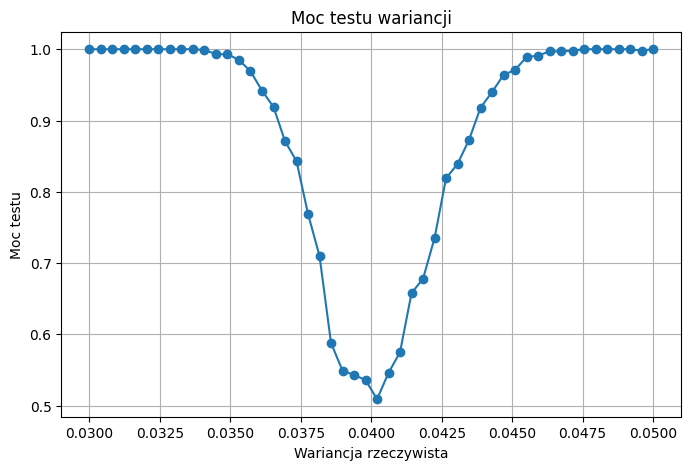

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    sigma_2_alter,
    moc_lista,
    marker='o'
)

plt.xlabel("Wariancja rzeczywista")
plt.ylabel("Moc testu")
plt.title("Moc testu wariancji")

plt.grid(True)
plt.show()